In [1]:
import pandas as pd

Učitavanje skupa podataka o perunikama (lat. *iris*): 

<img src="iris_petal-sepal.png" style="width: 250px; margin-left: 0.8cm;" align="left"/>

In [2]:
dataset = pd.read_csv('iris.csv')

In [3]:
type(dataset)

pandas.core.frame.DataFrame

### O skupu podataka

Prikaz prvih nekoliko redova tabele (preview):

In [4]:
dataset.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Dimenzije tabele:

In [5]:
dataset.shape

(150, 5)

Dakle, u skupu podataka imamo 150 instanci (redova tabele) i 5 atributa (kolone tabele).

Osnovne informacije o atributima, njihove tipove i uvid u prisustvo nedostajacih vrednosti mogu se dobiti metodom <code>info()</code>.

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal_Length  150 non-null    float64
 1   Sepal_Width   150 non-null    float64
 2   Petal_Length  150 non-null    float64
 3   Petal_Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Prikazati samo informacije o tipovima podataka svih kolona:

In [7]:
dataset.dtypes

Sepal_Length    float64
Sepal_Width     float64
Petal_Length    float64
Petal_Width     float64
Species          object
dtype: object

### Analiza kategoričkih atributa

Skup vrednosti kategoričkog atributa <code>Species</code>:

In [8]:
set(dataset['Species'])

{'setosa', 'versicolor', 'virginica'}

Promeniti tip atributa <code>Species</code> u <code>category</code>. Tip podataka <code>category</code> je posebno koristan kada radimo sa rednim atributima jer dozvoljavaju definisanje uređenja nad kategorijama.

In [9]:
dataset['Species'] = dataset['Species'].astype('category')

In [10]:
dataset.dtypes

Sepal_Length     float64
Sepal_Width      float64
Petal_Length     float64
Petal_Width      float64
Species         category
dtype: object

In [11]:
dataset['Species'].cat.categories

Index(['setosa', 'versicolor', 'virginica'], dtype='object')

Definisanje uređenja nad kategoričkim atributom može se izvršiti na jedan od sledeća dva načina:
    
<code>df[column_name] = df[column_name].cat.reorder_categories([cat_value_1, cat_value_2, cat_value_3], ordered=True)</code>

<code>df[column_name] = df[column_name].cat.set_categories([cat_value_1, cat_value_2, cat_value_3], ordered=True)</code>

U našem primeru to nema smisla tako da to nećemo raditi.

Grafički prikazati broj instanci po kategorijama atributa <code>Species</code>.

In [12]:
dataset['Species'].value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<Axes: xlabel='Species'>

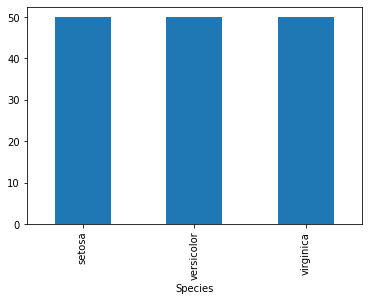

In [13]:
dataset['Species'].value_counts().plot.bar()

*II način:*

<Axes: >

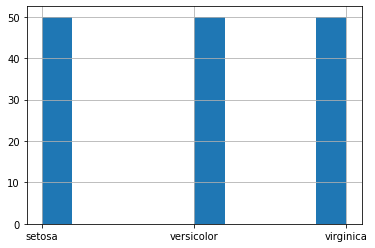

In [14]:
dataset['Species'].hist()

Binarizovati kategorički atribut <code>Species</code>:

In [15]:
pd.get_dummies(dataset, columns=['Species'])

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species_setosa,Species_versicolor,Species_virginica
0,5.1,3.5,1.4,0.2,True,False,False
1,4.9,3.0,1.4,0.2,True,False,False
2,4.7,3.2,1.3,0.2,True,False,False
3,4.6,3.1,1.5,0.2,True,False,False
4,5.0,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,False,False,True
146,6.3,2.5,5.0,1.9,False,False,True
147,6.5,3.0,5.2,2.0,False,False,True
148,6.2,3.4,5.4,2.3,False,False,True


### Analiza kvantitativnih atributa

Metod <code>describe()</code> racuna elementarne (deskriptivne) statistike atributa, kao sto su srednja vrednost, standardna devijacija, minimalna i maksimalna vrednost, 25%, 50% i 70% percentil vrednosti (vrednost atributa ispod koje se nalazi odgovarajući procenat instanci, 50% percentil je zapravo medijana).

In [16]:
numeric_columns = ['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width'] 

In [17]:
dataset[numeric_columns].describe()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
mean = dataset[numeric_columns].describe().loc['mean', :]
mean

Sepal_Length    5.843333
Sepal_Width     3.057333
Petal_Length    3.758000
Petal_Width     1.199333
Name: mean, dtype: float64

In [19]:
Sepal_Length_mean = mean['Sepal_Length']
Sepal_Length_mean

5.843333333333334

Izračunati dužinu interkvartilnog raspona atributa <code>Petal_Width</code>.

In [20]:
Q1 = dataset[numeric_columns].describe().loc['25%', :]
Q1

Sepal_Length    5.1
Sepal_Width     2.8
Petal_Length    1.6
Petal_Width     0.3
Name: 25%, dtype: float64

In [21]:
Petal_Width_Q1 = Q1['Petal_Width']
Petal_Width_Q1

0.3

In [22]:
Petal_Width_Q3 = dataset[numeric_columns].describe().loc['75%', 'Petal_Width']
Petal_Width_Q3

1.8

In [23]:
Petal_Width_IQR = Petal_Width_Q3 - Petal_Width_Q1
Petal_Width_IQR

1.5

Graficki prikaz raspodela pojedinacnih atributa mozemo dobiti metodom <code>hist()</code>.

array([[<Axes: title={'center': 'Sepal_Length'}>,
        <Axes: title={'center': 'Sepal_Width'}>],
       [<Axes: title={'center': 'Petal_Length'}>,
        <Axes: title={'center': 'Petal_Width'}>]], dtype=object)

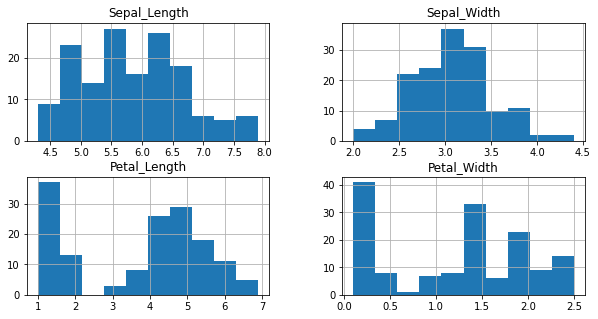

In [24]:
dataset.hist(figsize=(10, 5))

Diskretizovati vrednosti svih kontinualnih atributa segmentisanjem u 5 jednakih podintervala.

In [25]:
pd.cut(dataset['Sepal_Length'], bins=5, labels=[1, 2, 3, 4, 5])

0      2
1      1
2      1
3      1
4      1
      ..
145    4
146    3
147    4
148    3
149    3
Name: Sepal_Length, Length: 150, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [26]:
dataset[numeric_columns].apply(pd.cut, bins=5, labels=[1, 2, 3, 4, 5])

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,2,4,1,1
1,1,3,1,1
2,1,3,1,1
3,1,3,1,1
4,1,4,1,1
...,...,...,...,...
145,4,3,4,5
146,3,2,4,4
147,4,3,4,4
148,3,3,4,5
